## Testing coupling.py

## Import and Preprocess

In [1]:
# ================================
# eLoss-only notebook (publication styling)
# ================================
import numpy as np
import sys
import matplotlib.pyplot as plt

# -- modules --
sys.path.append("../code")

from particle import Particle
from coupling import alpha_s_provider, alpha_s

In [2]:
# Particles
P_b = Particle(family="bottomonia", state="avg")
P_c = Particle(family="charmonia",  state="avg")
roots = 8160.0      # GeV (8.16 TeV); try 5023.0 too
LA_fm = 10.11       # default Pb min-bias; swap from glauber later

P_b.print_summary(roots)
P_c.print_summary(roots)

# Grids
pT = np.linspace(0.0, 30.0, 400)
y  = np.linspace(-5.5, 5.5, 501)

[Particle] Upsilon  M=10.0100 GeV  pp:(p0=6.6, m=2.8, n=13.8), sqrt(s)=8160 GeV
[Particle] JPsi  M=3.4300 GeV  pp:(p0=4.2, m=3.5, n=19.2), sqrt(s)=8160 GeV


In [3]:
# -------------------------------
# 1) Running vs constant αs at μ = m_T(pT)
# -------------------------------
pT = np.linspace(0.0, 30.0, 200)
mu_b = P_b.mT(pT)
mu_c = P_c.mT(pT)

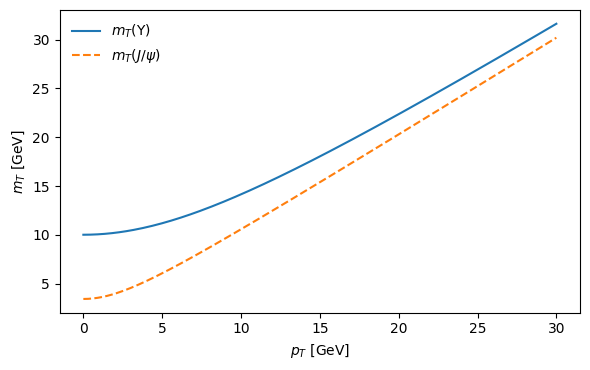

In [4]:
# mT vs pT for sanity
mu_b = P_b.mT(pT)
mu_c = P_c.mT(pT)
plt.figure(figsize=(6.0,3.8))
plt.plot(pT, mu_b, label=r"$m_T(\Upsilon)$")
plt.plot(pT, mu_c, label=r"$m_T(J/\psi)$", ls="--")
plt.xlabel(r"$p_T$ [GeV]"); plt.ylabel(r"$m_T$ [GeV]")
plt.legend(frameon=False); plt.tight_layout(); plt.show()

In [5]:
# -------------------------------
# Accuracy/sanity checks
# -------------------------------
a_run_4L = alpha_s_provider(mode="running", loops=4, method="ode")
print("Expected αs(muRef=1.5 GeV) ≈ 0.326:")
print("  4-loop ODE :", a_run_4L(1.5))
print("  4-loop asym:", alpha_s(1.5, loops=4, method="asym"))

print("\nBehavior near the pole (Λ=0.308 GeV):")
print("  αs(Λ_QCD) (frozen) =", a_run_4L(0.308))  # will print 1.0 by default

Expected αs(muRef=1.5 GeV) ≈ 0.326:
  4-loop ODE : 0.326
  4-loop asym: 0.33428356212394517

Behavior near the pole (Λ=0.308 GeV):
  αs(Λ_QCD) (frozen) = 1.0


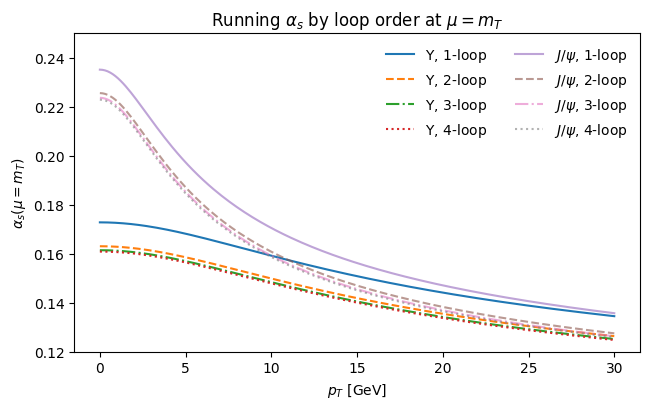

In [12]:
# -------------------------------
# Compare loop orders at μ = mT(pT)
# -------------------------------
styles = {1:"-", 2:"--", 3:"-.", 4:":"}
plt.figure(figsize=(6.6,4.2))

for loops in (1,2,3,4):
    a_run = alpha_s_provider(mode="running", loops=loops, method="ode")
    plt.plot(pT, [a_run(m) for m in mu_b],
             styles[loops], label=fr"$\Upsilon$, {loops}-loop")

for loops in (1,2,3,4):
    a_run = alpha_s_provider(mode="running", loops=loops, method="ode")
    plt.plot(pT, [a_run(m) for m in mu_c],
             styles[loops], alpha=0.6, label=fr"$J/\psi$, {loops}-loop")

a_const = alpha_s_provider(mode="constant", alpha0=0.326)
# plt.hlines([0.326], 0, pT.max(), linestyles=":", colors="k", label=r"const $\alpha_s=0.326$")

plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel(r"$\alpha_s(\mu=m_T)$")
plt.title(r"Running $\alpha_s$ by loop order at $\mu=m_T$")
plt.ylim(0.12, 0.25)
plt.legend(ncol=2, frameon=False)
plt.tight_layout(); plt.show()